In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

plt.style.use("seaborn-v0_8-whitegrid")

OUTPUT_DIR = Path.cwd()

In [2]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)

y = pd.Series(wine.target, name="target")

display(X.head())

print(f"Розмір матриці ознак: {X.shape[0]} рядків x {X.shape[1]} ознак")
print(f"Класи: {list(wine.target_names)}")

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


Розмір матриці ознак: 178 рядків x 13 ознак
Класи: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


In [3]:
scale_summary = pd.DataFrame({"mean_before": X.mean(),"std_before": X.std()}).round(2)

display(scale_summary)

,mean_before,std_before
alcohol,13.00,0.81
malic_acid,2.34,1.12
ash,2.37,0.27
alcalinity_of_ash,19.49,3.34
magnesium,99.74,14.28
total_phenols,2.30,0.63
flavanoids,2.03,1.00
nonflavanoid_phenols,0.36,0.12
proanthocyanins,1.59,0.57
color_intensity,5.06,2.32


In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

scaled_summary = (pd.DataFrame(X_scaled, columns=X.columns).agg(["mean", "std"]).T)

display(scaled_summary.round(2))

,mean,std
alcohol,-0.0,1.0
malic_acid,-0.0,1.0
ash,-0.0,1.0
alcalinity_of_ash,-0.0,1.0
magnesium,-0.0,1.0
total_phenols,0.0,1.0
flavanoids,-0.0,1.0
nonflavanoid_phenols,0.0,1.0
proanthocyanins,-0.0,1.0
color_intensity,0.0,1.0


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (142, 13)
Test: (36, 13)


In [6]:
pca_2d = PCA(n_components=2)

X_pca = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

pca_df["target"] = y

display(pca_df.head())

,PC1,PC2,target
0,3.316751,1.443463,0
1,2.209465,-0.333393,0
2,2.516740,1.031151,0
3,3.757066,2.756372,0
4,1.008908,0.869831,0


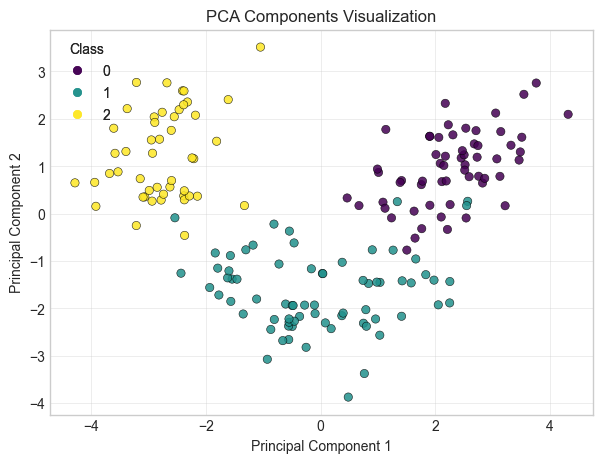

In [7]:
fig, ax = plt.subplots(figsize=(7,5))

scatter = ax.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["target"],
    cmap="viridis",
    edgecolor="black",
    linewidth=0.4,
    alpha=0.85
)

ax.set_title("PCA Components Visualization")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")

legend = ax.legend(*scatter.legend_elements(),title="Class")

ax.add_artist(legend)

plt.show()

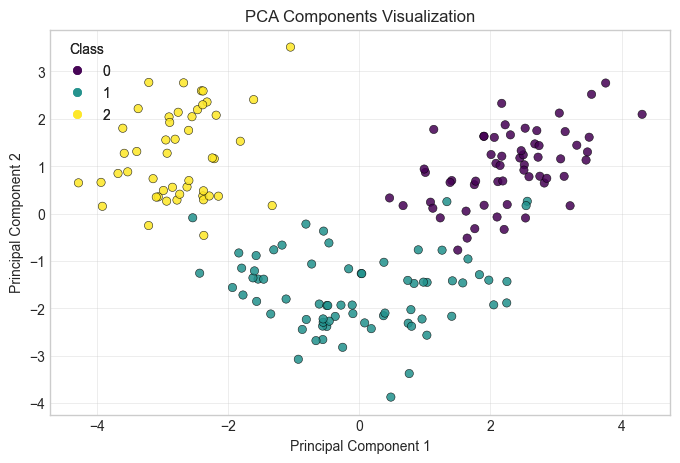

Зображення збережено: E:\PythonAI\notebook\pca_projection_student.png


In [8]:
fig, ax = plt.subplots(figsize=(8,5))

scatter = ax.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["target"],
    cmap="viridis",
    edgecolor="black",
    linewidth=0.4,
    alpha=0.85
)

ax.set_title("PCA Components Visualization")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")

legend = ax.legend(*scatter.legend_elements(), title="Class")

ax.add_artist(legend)

projection_path = OUTPUT_DIR / "pca_projection_student.png"

fig.savefig(projection_path, dpi=160, bbox_inches="tight")

plt.show()

print("Зображення збережено:", projection_path)

In [9]:
explained = pd.Series(
    pca_2d.explained_variance_ratio_,
    index=["PC1", "PC2"],
    name="explained_variance_ratio"
)

display(explained.to_frame().round(3))

print(f"Разом перші 2 компоненти пояснюють: {explained.sum():.1%} варіативності")

,explained_variance_ratio
PC1,0.362
PC2,0.192


Разом перші 2 компоненти пояснюють: 55.4% варіативності


In [10]:
pca_full = PCA()

pca_full.fit(X_scaled)

variance_df = pd.DataFrame({"component": range(1, len(pca_full.explained_variance_ratio_) + 1), "explained": pca_full.explained_variance_ratio_})

variance_df["cumulative"] = variance_df["explained"].cumsum()

components_for_90 = variance_df.loc[variance_df["cumulative"] >= 0.90, "component"].iloc[0]

display(variance_df.round(3))

print(f"Для пояснення >= 90% варіативності потрібно компонентів: {components_for_90}")

,component,explained,cumulative
0,1,0.362,0.362
1,2,0.192,0.554
2,3,0.111,0.665
3,4,0.071,0.736
4,5,0.066,0.802
5,6,0.049,0.851
6,7,0.042,0.893
7,8,0.027,0.920
8,9,0.022,0.942
9,10,0.019,0.962


Для пояснення >= 90% варіативності потрібно компонентів: 8


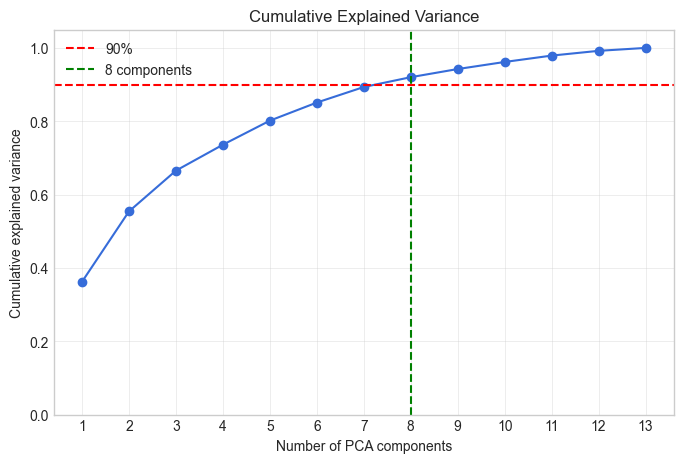

In [11]:
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(
    variance_df["component"],
    variance_df["cumulative"],
    marker="o"
)

ax.axhline(
    0.90,
    color="red",
    linestyle="--",
    label="90%"
)

ax.axvline(
    components_for_90,
    color="green",
    linestyle="--",
    label=f"{components_for_90} components"
)

ax.set_title("Cumulative Explained Variance")
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Cumulative explained variance")
ax.set_xticks(variance_df["component"])
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()

In [12]:
components = [2, 5, 10]
accuracies = []

for n in components:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    model = LogisticRegression(
        random_state=42,
        max_iter=1000
    )
    model.fit(X_train_pca, y_train)
    predictions = model.predict(X_test_pca)
    accuracy = accuracy_score(
        y_test,
        predictions
    )
    accuracies.append(accuracy)

    print(f"PCA components = {n}: Accuracy = {accuracy:.4f}")

PCA components = 2: Accuracy = 0.9167
PCA components = 5: Accuracy = 0.9722
PCA components = 10: Accuracy = 0.9722


In [13]:
results = pd.DataFrame({"Components": components, "Accuracy": accuracies})

display(results)

,Components,Accuracy
0,2,0.916667
1,5,0.972222
2,10,0.972222


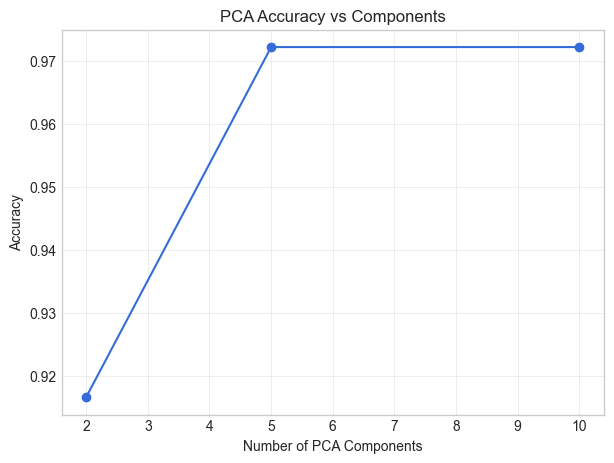

In [14]:
fig, ax = plt.subplots(figsize=(7,5))

ax.plot(
    components,
    accuracies,
    marker="o"
)

ax.set_title("PCA Accuracy vs Components")
ax.set_xlabel("Number of PCA Components")
ax.set_ylabel("Accuracy")
plt.show()

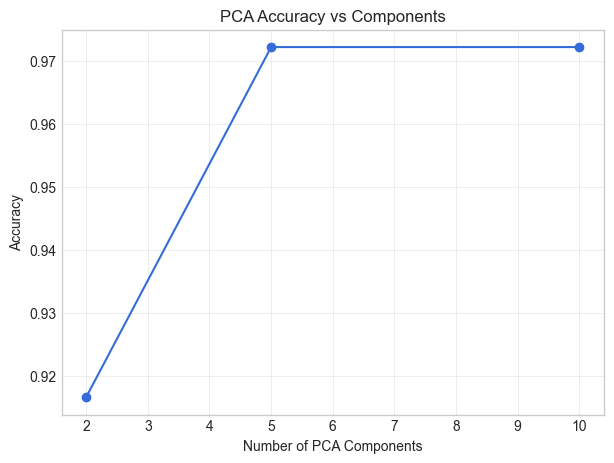

Графік збережено: E:\PythonAI\notebook\pca_accuracy_results.png


In [15]:
fig, ax = plt.subplots(figsize=(7,5))

ax.plot(
    components,
    accuracies,
    marker="o"
)

ax.set_title("PCA Accuracy vs Components")
ax.set_xlabel("Number of PCA Components")
ax.set_ylabel("Accuracy")
accuracy_path = OUTPUT_DIR / "pca_accuracy_results.png"

fig.savefig(
    accuracy_path,
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print("Графік збережено:", accuracy_path)


Перед застосуванням PCA необхідно масштабувати ознаки, оскільки вони мають різні одиниці вимірювання та діапазони значень. Без стандартизації ознаки з більшими значеннями будуть мати більший вплив на головні компоненти.

Перші дві головні компоненти пояснюють більшу частину варіативності даних, але не всю інформацію. Для пояснення приблизно 90% варіативності потрібно більше компонентів.

Під час експерименту зі збільшенням кількості компонентів якість класифікації покращувалася або залишалася майже незмінною. Найкращий результат показав варіант із найбільшою кількістю компонентів серед досліджених.

Двовимірна PCA-візуалізація добре показує загальну структуру даних, але не може повністю відобразити інформацію, що міститься у всіх 13 початкових ознаках.